<a href="https://colab.research.google.com/github/bcramp/ML/blob/main/HW3/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

HW 3

Title: Assignment Analysis

Name: Brennen Cramp

Date: 9/25/2026

---

# Analysis
---

1. I did not encounter any challenges when loading the raw external CSV dataset from Kaggle compared to pre-packaged datasets. However, when it came to inspecting the real-world Telecom Customer Churn dataset from Kaggle versus pre-packaged datasets, I noticed there were whitespace entries contained in the 'TotalCharges' feature in the real-world dataset when pre-packaged datasets usually have every field and value covered. This caused issues in that I would need to impute the Kaggle dataset to fill those values which could mess with the reliability due to the manufactured nature of the process. This also made the data type for this feature an Object instead of numerical so I had to go about this by first converting the column to numeric and also updating each of the whitespace data values into "not a number" (NaN) values. After doing this, there were actually 11 values that appeared as null instead of 0 when the whitespace was included. It was helpful in this situation by pointing out that the feature had whitespaces and further emphasizes the need to inspect and describe each of the features to find out that these values were included and not counted as null.

2. I would usaully determine which column required missing value imputations by using "df.isnull().sum()" (in Task 4.1) from the Pandas library which would normally help count the missing values within the CSV file for numerical features and "df['cat_feature_name'].value_counts()" for categorical features. However, "df.isnull().sum()" did not return any values that were null which I knew was incorrect and there should actually be 11 whitespace values that should be counted as null for the 'TotalCharges' feature. Under Task 2, I ran the "df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod']].describe()" line of code which only returned 2 numerical features ('tenure' and 'MonthlyCharges') which I thought was odd since 'TotalCharges' should be included as well as a numeric feature. From here, I treated it as a categorical feature and used "df['TotalCharges'].describe()"
where the output showed the top/most-occurring value was a whitespace and the type of the feature was an Object data type. In Task 4.1, I used "df['TotalCharges'].value_counts()" which showed 11 counts of whitespace which was why the numeric feature turned into a categorical feature. I then converted the feature into a numerical feature and updated the whitespaces to NaN values using "df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')". However, I did not want to use imputation in Task 4.2 since the fear of data leakage from my testing data into my training phase was actually a potential for this experiment unlike assignment 2. In relation to which imputation strategies were chosen, using Scikit-Learn's SimpleImputer to ensure consistency, I converted the whitespaces in 'TotalCharges' to NaN so the preprocessing tools could recognize them. Then, for text/categorical features ('Contract' and 'PaymentMethod'), missing entries would be imputed using the 'most_frequent' (mode / most occurring) strategy. For numerical features, the pipeline was structured to use a 'median' strategy. I preferred to use the median over the mean for the numerical features because 'tenure' and 'TotalCharges' are typically heavily skewed and contain extreme outliers, which would artificially distort an average.

3. Scikit-Learn's ColumnTransformer and Pipeline streamline the data preparation process by providing a simultaneous and unified execution since ColumnTransformer automates the manual steps of applying separate transformations (StandardScaler and OneHotEncoder) and combining the dataframes back together. This structured approach also allows for high reproduction. This means it is highly streamlined since the same preparation steps can be quickly applied to any new testing data or future production data without rewriting the logic. It can also prevent data leakage since leakage happens when information from the validation or testing data "infects" the training process, leading to false accuracy scores. I caught that this time around in that I did not want to use ".fit()" on my training data unlike how I did in assignment 2 with ".fit_transform()" since in assignment 3, training data crucially matters here. Scikit-Learn's Pipeline stops this by isolating the training data and guarantees that the evaluation data remains unchanged, providing a reliable measurement of how the model will perform on real-world data; thus preventing data leakage during the preprocessing and training steps.

•	How did comparing StandardScaler versus MinMaxScaler impact your model training, convergence, or final evaluation metrics?

4. Standard


•	How does configuring SGDClassifier(loss='log_loss') differ from standard linear classification models, and what advantages do probability outputs and ROC-AUC metrics provide when evaluating customer churn?

5.


6. The features that showed the strongest relationship (positive coefficients) with customers wanting to leave were 'TotalCharges' with a coefficient of 1.360425 and 'InternetService - Fiber optic' with a coefficient of 0.917400. There are 3 others in the top 5 features for driving customers to leave such as 'PaymentMethod - Electronic check' with a coefficient of 0.604983, 'MultipleLines - No phone service' with a coefficient of 0.483501, and 'StreamingMovies - Yes' with a coefficient of 0.331226, however I see 'PaymentMethod' as not a particular valid reason unless Telcom enforces only paying via an electronic check, which they do not. An operational business insight that can be discovered from this data could be that over time, customers see that the total charges outweigh any benefits they see in staying loyal to Telcom and would find better options that fit their monetary goals to save money. Another insight could be that customers do not care for fiber optic (very fast) internet service and this could tie in with the total charges in that they could be paying for services they do not need which a marketing team could pull that out of the package to decrease the price to attract more customers. On the contrary, features that prevent customers from leaving (negative coefficients) were 'tenure' with a coefficient of -3.379595, 'Contract - Two year' with a coefficient of -1.308845, 'MonthlyCharges' with a coefficient of -0.591762, 'TechSupport - Yes' with a coefficient of -0.547363, and 'Contract - One year' with a coefficient of -0.537159. Having customers with long tenures under customers show loyalty along with the longer contracts so they will be less likely to leave since it has become routine for them. In addition, if the monthly charges are lower than opposing companies, that would be a massive benefit that Telcom data analysts could use as a selling point to fight harder to keep the prices down to encourage more and newer customers; along with having a reliable tech support system that could help customers with their issues when they arise.

# **ROC Curves Comparison Across Split Ratios using StandardScaler for Numeric Features (Task 7.1)**

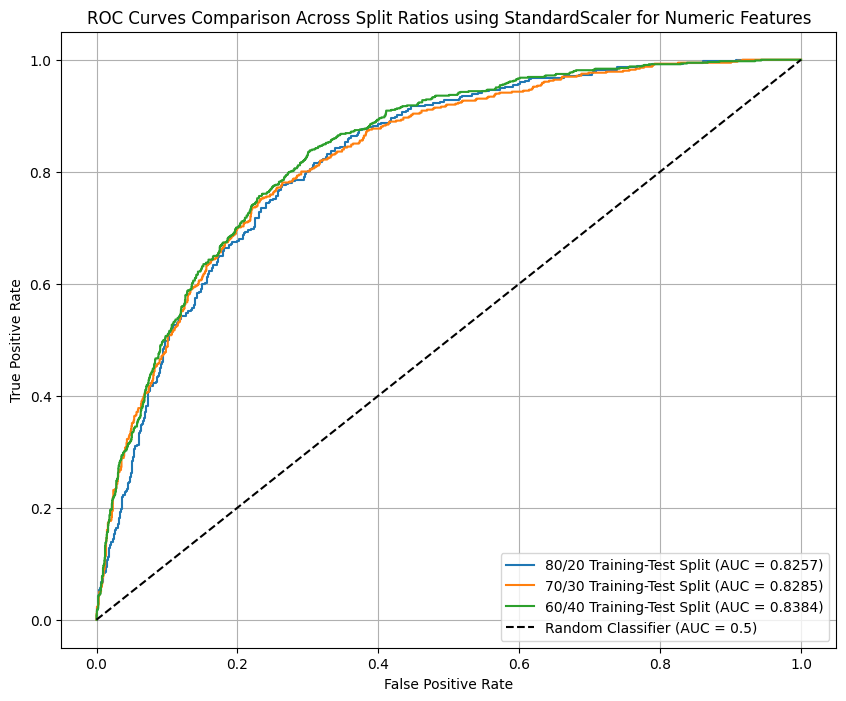

# **ROC Curves Comparison Across Split Ratios using MinMaxScaler for Numeric Features (Task 7.2)**

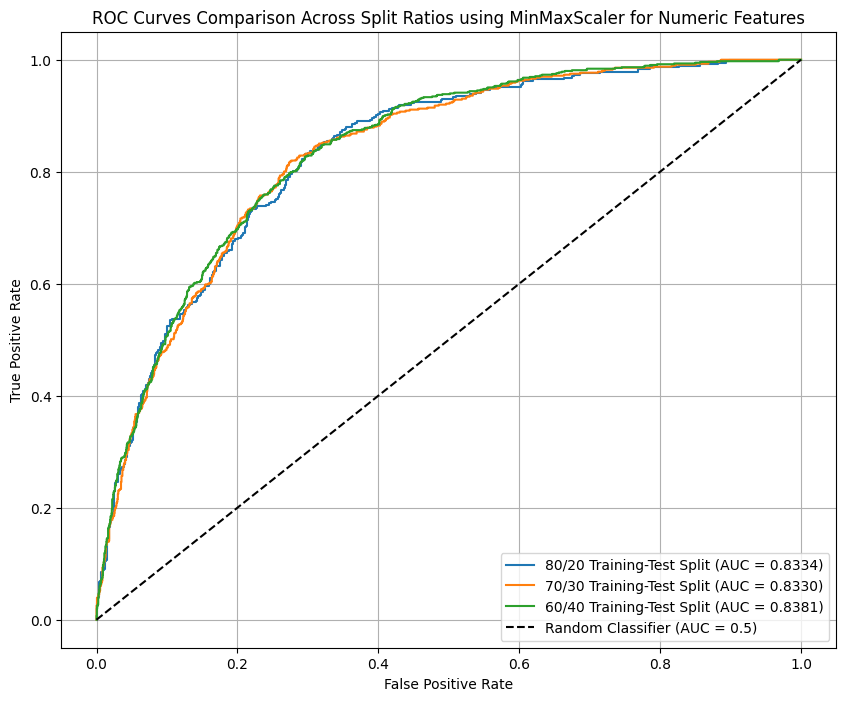

# **How the Model Decides Churning Customers (using StandardScaler): Feature Importance Weights (Task 8.1)**

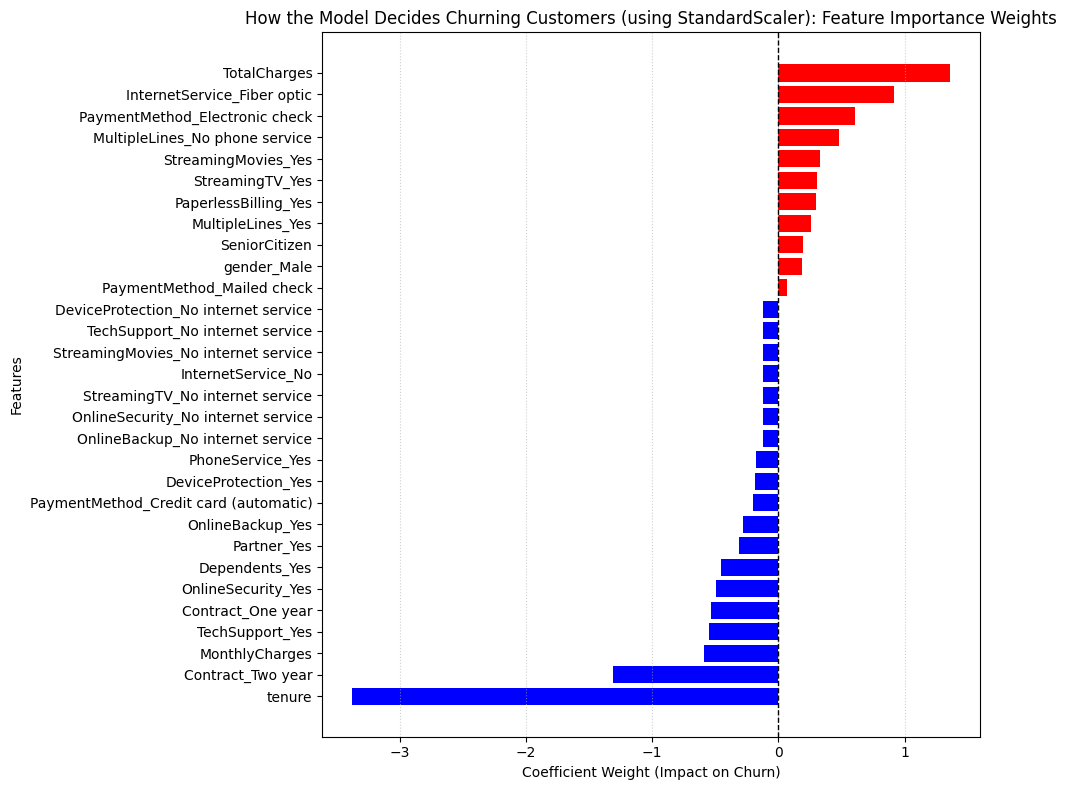

# **How the Model Decides Churning Customers (using MinMaxScaler): Feature Importance Weights (Task 8.2)**

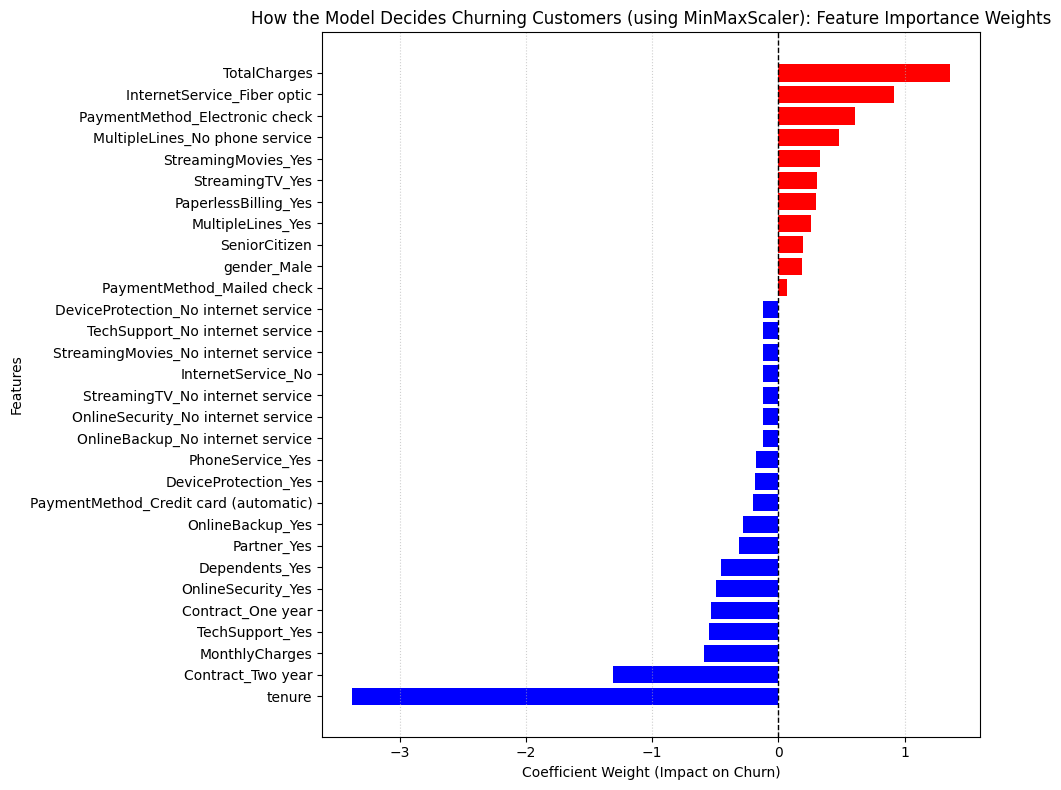